In [37]:
import fastf1
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [ ]:
fastf1.Cache.enable_cache('../data/cache')

In [10]:
quali2025 = pd.read_csv('../data/processed/quali_2025.csv')
print(quali2025.head())

  Piloto           Equipe      S1      S2      S3  Tempo de Volta  Position  \
0    NOR          McLaren  25.961  16.997  32.138          75.096         1   
1    PIA          McLaren  26.082  16.952  32.146          75.180         2   
2    VER  Red Bull Racing  26.066  16.915  32.500          75.481         3   
3    RUS         Mercedes  26.163  16.951  32.432          75.546         4   
4    TSU     Racing Bulls  26.190  17.005  32.475          75.670         5   

    Ano                     GP  
0  2025  Australian Grand Prix  
1  2025  Australian Grand Prix  
2  2025  Australian Grand Prix  
3  2025  Australian Grand Prix  
4  2025  Australian Grand Prix  


In [12]:
quali2025.shape

(475, 9)

In [13]:
quali2025.dtypes

Piloto             object
Equipe             object
S1                float64
S2                float64
S3                float64
Tempo de Volta    float64
Position            int64
Ano                 int64
GP                 object
dtype: object

In [19]:
quali2025.groupby('GP').size()

GP
Abu Dhabi Grand Prix         20
Australian Grand Prix        19
Austrian Grand Prix          20
Azerbaijan Grand Prix        20
Bahrain Grand Prix           20
Belgian Grand Prix           20
British Grand Prix           20
Canadian Grand Prix          20
Chinese Grand Prix           20
Dutch Grand Prix             19
Emilia Romagna Grand Prix    19
Hungarian Grand Prix         20
Italian Grand Prix           20
Japanese Grand Prix          20
Las Vegas Grand Prix         20
Mexico City Grand Prix       20
Miami Grand Prix             20
Monaco Grand Prix            20
Qatar Grand Prix             20
Saudi Arabian Grand Prix     20
Singapore Grand Prix         20
Spanish Grand Prix           20
São Paulo Grand Prix         19
United States Grand Prix     19
dtype: int64

In [24]:
gpbahrain = quali2025[quali2025['GP'] == 'Bahrain Grand Prix']
print(gpbahrain)

   Piloto           Equipe      S1      S2      S3  Tempo de Volta  Position  \
59    PIA          McLaren  28.784  38.574  22.483          89.841         1   
60    RUS         Mercedes  28.771  38.710  22.528          90.009         2   
61    LEC          Ferrari  28.926  38.714  22.535          90.175         3   
62    ANT         Mercedes  28.836  38.786  22.591          90.213         4   
63    GAS           Alpine  28.883  38.694  22.639          90.216         5   
64    NOR          McLaren  29.007  38.678  22.582          90.267         6   
65    VER  Red Bull Racing  28.880  38.855  22.688          90.423         7   
66    SAI         Williams  28.894  39.063  22.723          90.680         8   
67    HAM          Ferrari  28.955  39.058  22.759          90.772         9   
68    TSU  Red Bull Racing  29.067  39.177  22.984          91.228        10   
69    DOO           Alpine  29.094  39.215  22.936          91.245        11   
70    HAD     Racing Bulls  29.081  39.2

In [26]:
stats.spearmanr(gpbahrain['S1'], gpbahrain['Position'])

SignificanceResult(statistic=np.float64(0.9383458646616539), pvalue=np.float64(9.762241109318062e-10))

In [27]:
stats.spearmanr(gpbahrain['S2'], gpbahrain['Position'])

SignificanceResult(statistic=np.float64(0.956390977443609), pvalue=np.float64(4.622988667749734e-11))

In [28]:
stats.spearmanr(gpbahrain['S3'], gpbahrain['Position'])

SignificanceResult(statistic=np.float64(0.9067669172932331), pvalue=np.float64(3.589233262466606e-08))

In [31]:
lista_resultados = []

for gp, dados in quali2025.groupby('GP'):
    resultado_s1 = stats.spearmanr(dados['S1'], dados ['Position'])
    resultado_s2 = stats.spearmanr(dados['S2'], dados ['Position'])
    resultado_s3 = stats.spearmanr(dados['S3'], dados ['Position'])

    registro = {'GP': gp, 'rho_s1': resultado_s1.statistic, 'rho_s2': resultado_s2.statistic, 'rho_s3': resultado_s3.statistic}

    lista_resultados.append(registro)

In [33]:
tabela_correlacoes = pd.DataFrame(lista_resultados)
tabela_correlacoes.shape

(24, 4)

In [34]:
tabela_correlacoes.head()

,GP,rho_s1,rho_s2,rho_s3
0,Abu Dhabi Grand Prix,0.640602,0.803008,0.894321
1,Australian Grand Prix,0.964912,0.856140,0.950877
2,Austrian Grand Prix,0.765414,0.685714,0.906767
3,Azerbaijan Grand Prix,0.733835,0.890226,0.219631
4,Bahrain Grand Prix,0.938346,0.956391,0.906767


In [36]:
tabela_correlacoes.describe()

,rho_s1,rho_s2,rho_s3
count,24.000000,24.000000,24.000000
mean,0.808868,0.891820,0.816632
std,0.150829,0.075400,0.176873
min,0.363910,0.685714,0.219631
25%,0.757519,0.841601,0.815207
50%,0.858683,0.924233,0.872932
75%,0.914262,0.956391,0.907775
max,0.964912,0.969925,0.964272


## Análise 1: Correlação entre setores do quali e posição de grid

**Objetivo:** verificar se existe correlação estatística entre o tempo de cada setor da qualificação e a posição final no grid de largada, ao longo da temporada 2025.

**Metodologia:**
- Como cada corrida acontece em uma pista diferente (tempos não comparáveis diretamente entre GPs), a correlação foi calculada separadamente por corrida (`groupby('GP')`), usando o coeficiente de **Spearman** — apropriado aqui porque a posição de grid é uma variável ordinal (rank), e a relação não é necessariamente linear.
- Para cada uma das 24 corridas da temporada, calculei o rho entre `S1`, `S2`, `S3` e `Position`, gerando uma tabela de 24 linhas com uma correlação por setor por corrida.

**Resultados gerais da temporada (`.describe()`):**
- S1: média = 0.81 | desvio padrão = 0.15
- S2: média = 0.89 | desvio padrão = 0.075 (o mais forte **e** mais consistente)
- S3: média = 0.82 | desvio padrão = 0.18 (o mais instável)

**Conclusão:**
Os três setores apresentam correlação forte e positiva com a posição de largada ao longo da temporada — ser rápido no quali realmente se traduz em largar na frente. O **Setor 2** é o mais consistente (maior média, menor variação entre corridas), provavelmente porque é um setor mais técnico/misto, que exige um equilíbrio de setup aerodinâmico que as equipes não conseguem "burlar" facilmente.

Já os setores **S1 e S3**, dominados por retas, mostram mais instabilidade — com destaque para dois casos extremos: **Azerbaijão** (S3, rho = 0.22) e **Bélgica** (S1 = 0.36 e S3 = 0.43). Duas explicações plausíveis, que se reforçam: (1) o efeito de vácuo/tráfego nas retas longas (a maior da F1 em Baku, e o trecho Eau Rouge → Kemmel em Spa) introduz ruído no tempo de setor que não reflete o ritmo real do carro; e (2) a escolha de configuração aerodinâmica de cada equipe — carros com pouca asa ganham tempo nas retas (S1/S3) mas perdem nas curvas técnicas (S2), e vice-versa — o que "desacopla" parcialmente o desempenho nesses setores do ritmo geral do carro (refletido na posição de grid). O restante das corridas fica numa faixa de 0.6 a 0.97, variação considerada normal para uma amostra de 24 corridas.

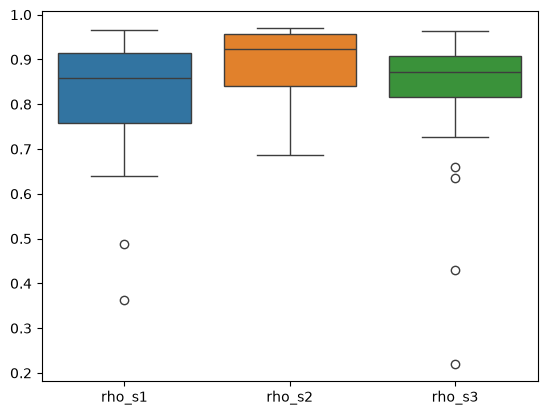

In [50]:
sns.boxplot(data=tabela_correlacoes[['rho_s1', 'rho_s2', 'rho_s3']])
plt.savefig('../reports/figures/analise1_setores_grids.png')
plt.show()

In [39]:
tabela_correlacoes.sort_values('rho_s1').head()

,GP,rho_s1,rho_s2,rho_s3
5,Belgian Grand Prix,0.363910,0.887552,0.430237
12,Italian Grand Prix,0.487218,0.860150,0.956391
0,Abu Dhabi Grand Prix,0.640602,0.803008,0.894321
11,Hungarian Grand Prix,0.656638,0.917638,0.824370
22,São Paulo Grand Prix,0.724561,0.831066,0.726316


In [40]:
tabela_correlacoes.sort_values('rho_s3').head()

,GP,rho_s1,rho_s2,rho_s3
3,Azerbaijan Grand Prix,0.733835,0.890226,0.219631
5,Belgian Grand Prix,0.363910,0.887552,0.430237
20,Singapore Grand Prix,0.774436,0.933835,0.636090
16,Miami Grand Prix,0.909774,0.953383,0.659895
22,São Paulo Grand Prix,0.724561,0.831066,0.726316


In [41]:
tabela_correlacoes.to_csv('../data/processed/correlacoes_setores_grid.csv', index=False)

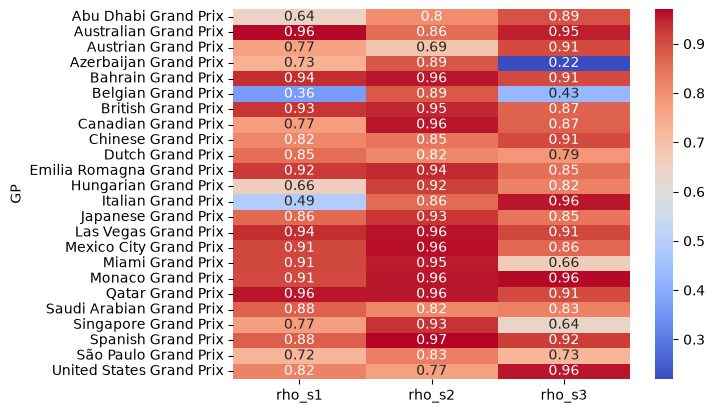

In [51]:
sns.heatmap(tabela_correlacoes.set_index('GP'), annot=True, cmap='coolwarm')
plt.savefig('../reports/figures/heatmap_setores_grid.png')
plt.show()

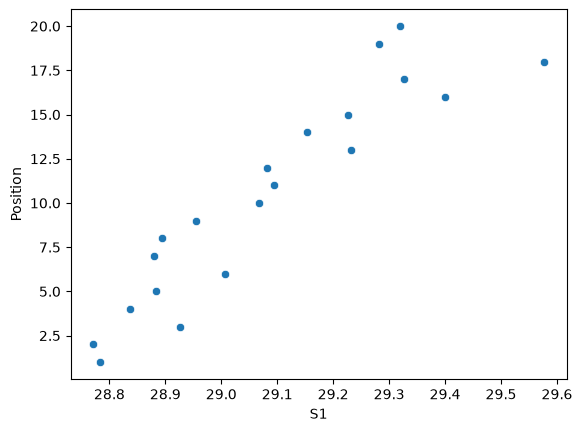

In [52]:
sns.scatterplot(data=gpbahrain, x='S1', y='Position')
plt.show()

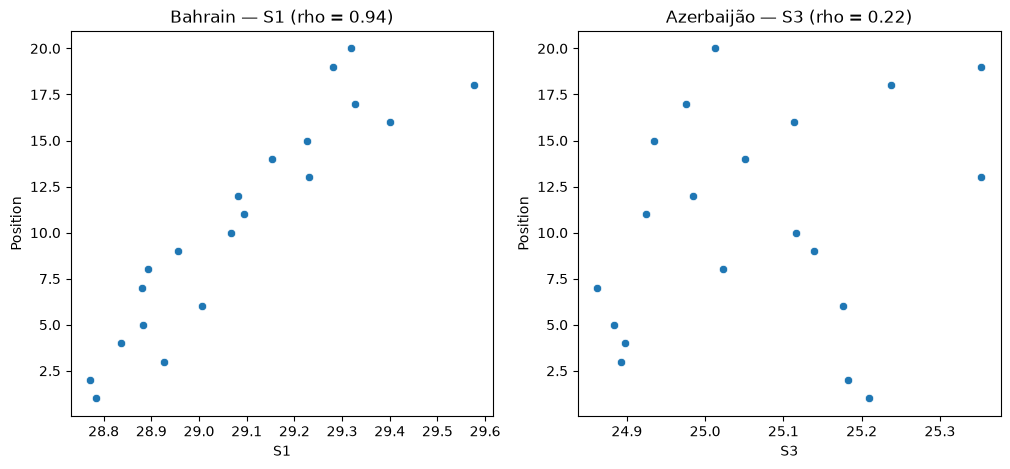

In [55]:
baku = quali2025[quali2025['GP'] == 'Azerbaijan Grand Prix']

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=gpbahrain, x='S1', y='Position', ax=eixos[0])
eixos[0].set_title('Bahrain — S1 (rho = 0.94)')

sns.scatterplot(data=baku, x='S3', y='Position', ax=eixos[1])
eixos[1].set_title('Azerbaijão — S3 (rho = 0.22)')

plt.savefig('../reports/figures/scatter_contraste_forte_fraco.png')
plt.show()

### Visualizações complementares

- **Heatmap (setor × corrida):** mostra visualmente as 24 corridas × 3 setores de uma vez, com as duas exceções (Azerbaijão S3, Bélgica S1/S3) aparecendo claramente em azul contra um mapa dominado por vermelho/laranja (correlação forte).
- **Scatter Bahrain (S1) vs. Azerbaijão (S3):** contraste direto entre um caso forte (rho = 0.94, pontos formando quase uma diagonal) e um caso fraco (rho = 0.22, pontos espalhados sem padrão claro) — visualiza o que os números de rho realmente significam na prática.